# Anhedonic AI — 7B vs 72B Comparison
Side-by-side comparison of reward neuron localization across model scales.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.patches import Patch

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

K_THRESHOLDS = [27, 30, 35, 40, 45, 50, 54]

# Paths
BASE_7B  = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1'
BASE_72B = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/72-Exp1'

SUBJECTS = [
    'abstract_algebra','anatomy','astronomy','business_ethics',
    'clinical_knowledge','college_biology','college_computer_science',
    'college_mathematics','college_medicine','computer_security',
    'conceptual_physics','econometrics','electrical_engineering',
    'elementary_mathematics','formal_logic','global_facts',
    'high_school_biology','high_school_chemistry','high_school_computer_science',
    'high_school_european_history','high_school_geography',
    'high_school_government_and_politics','high_school_macroeconomics',
    'high_school_mathematics','high_school_microeconomics','high_school_physics',
    'high_school_psychology','high_school_statistics','high_school_us_history',
    'high_school_world_history','human_aging','human_sexuality',
    'international_law','jurisprudence','logical_fallacies','machine_learning',
    'management','marketing','medical_genetics','miscellaneous','moral_disputes',
    'moral_scenarios','nutrition','philosophy','prehistory',
    'professional_accounting','professional_law','professional_medicine',
    'professional_psychology','public_relations','security_studies','sociology',
    'virology','world_religions'
]

print('Config ready.')

Config ready.


In [5]:
def load_set(path):
    df = pd.read_csv(path)
    return set(zip(df['layer'].tolist(), df['neuron'].tolist()))

def layer_dist(neuron_set, num_layers):
    c = defaultdict(int)
    for (l,_) in neuron_set: c[l] += 1
    return [c.get(l,0) for l in range(num_layers)]

def layer_dist_pct(neuron_set, num_layers):
    d = layer_dist(neuron_set, num_layers)
    t = len(neuron_set) if neuron_set else 1
    return [v/t*100 for v in d]

def band_count(s, l_start, l_end):
    return sum(1 for (l,_) in s if l_start <= l <= l_end)

# ── 7B ────────────────────────────────────────────────────────────────────────
B7 = {
    'orig_reward':  load_set(f'{BASE_7B}/phase4/extraction/universal_reward_neurons.csv'),
    'orig_money':   load_set(f'{BASE_7B}/phase4/extraction/universal_money_neurons.csv'),
    'orig_core':    load_set(f'{BASE_7B}/phase4/extraction/master_incentive_core.csv'),
    'asdiv_reward': load_set(f'{BASE_7B}/evaluation/ASDiv/extraction/asdiv_universal_reward_neurons.csv'),
    'asdiv_money':  load_set(f'{BASE_7B}/evaluation/ASDiv/extraction/asdiv_universal_money_neurons.csv'),
    'asdiv_core':   load_set(f'{BASE_7B}/evaluation/ASDiv/extraction/asdiv_master_incentive_core.csv'),
}
for k in K_THRESHOLDS:
    B7[f'mmlu_k{k}'] = load_set(f'{BASE_7B}/evaluation/mmlu/neurons/mmlu/cross_subject/k{k}.csv')
B7['shared'] = B7['mmlu_k54'] & B7['asdiv_core']
B7['triple'] = B7['mmlu_k54'] & B7['asdiv_core'] & B7['orig_core']

# ── 72B ───────────────────────────────────────────────────────────────────────
B72 = {
    'orig_reward':  load_set(f'{BASE_72B}/neurons/orig/universal_reward_neurons.csv'),
    'orig_money':   load_set(f'{BASE_72B}/neurons/orig/universal_money_neurons.csv'),
    'orig_core':    load_set(f'{BASE_72B}/neurons/orig/master_incentive_core.csv'),
    'asdiv_reward': load_set(f'{BASE_72B}/ASDiv/neurons/asdiv_universal_reward_neurons.csv'),
    'asdiv_money':  load_set(f'{BASE_72B}/ASDiv/neurons/asdiv_universal_money_neurons.csv'),
    'asdiv_core':   load_set(f'{BASE_72B}/ASDiv/neurons/asdiv_master_incentive_core.csv'),
}
for k in K_THRESHOLDS:
    B72[f'mmlu_k{k}'] = load_set(f'{BASE_72B}/MMLU/neurons/cross_subject/k{k}.csv')
B72['shared'] = B72['mmlu_k54'] & B72['asdiv_core']
B72['triple'] = B72['mmlu_k54'] & B72['asdiv_core'] & B72['orig_core']

print('All sets loaded.')
print(f'  7B  orig_core={len(B7["orig_core"])}, asdiv_core={len(B7["asdiv_core"])}, shared={len(B7["shared"])}, triple={len(B7["triple"])}')
print(f'  72B orig_core={len(B72["orig_core"])}, asdiv_core={len(B72["asdiv_core"])}, shared={len(B72["shared"])}, triple={len(B72["triple"])}')

All sets loaded.
  7B  orig_core=3528, asdiv_core=7913, shared=163, triple=29
  72B orig_core=11736, asdiv_core=29155, shared=421, triple=48


## 1 — Architecture comparison

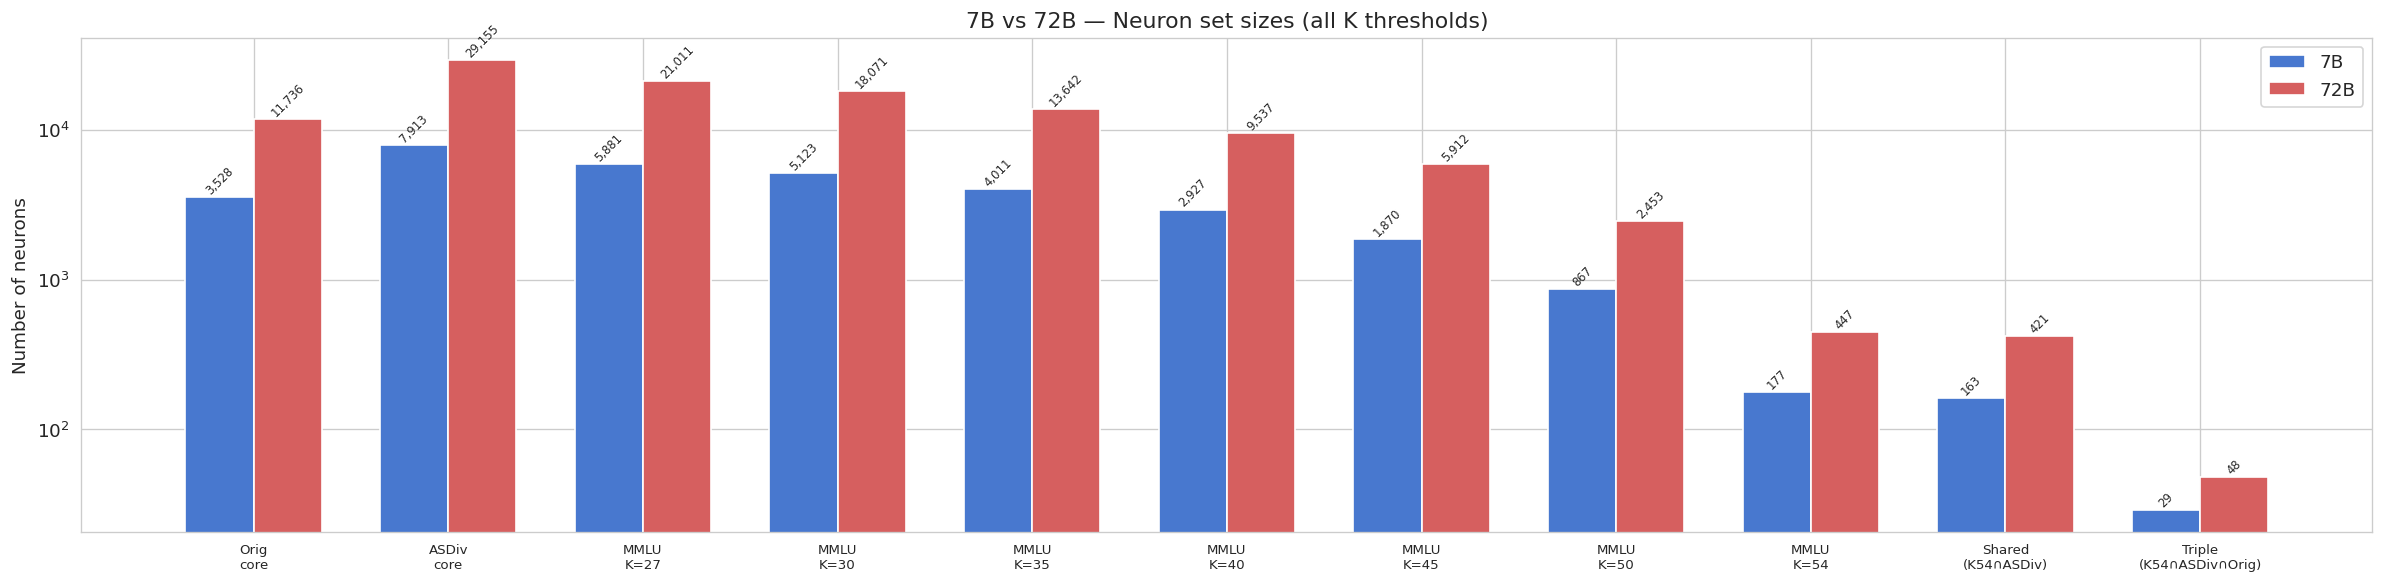

In [6]:
set_keys = ['orig_core','asdiv_core','mmlu_k27','mmlu_k30','mmlu_k35','mmlu_k40','mmlu_k45','mmlu_k50','mmlu_k54','shared','triple']
labels   = ['Orig\ncore','ASDiv\ncore','MMLU\nK=27','MMLU\nK=30','MMLU\nK=35','MMLU\nK=40','MMLU\nK=45','MMLU\nK=50','MMLU\nK=54','Shared\n(K54∩ASDiv)','Triple\n(K54∩ASDiv∩Orig)']

x  = np.arange(len(set_keys))
w  = 0.35
s7 = [len(B7[k])  for k in set_keys]
s72= [len(B72[k]) for k in set_keys]

fig, ax = plt.subplots(figsize=(20,5))
ax.bar(x-w/2, s7,  w, label='7B',  color='#4878CF', edgecolor='white')
ax.bar(x+w/2, s72, w, label='72B', color='#D65F5F', edgecolor='white')
for xi,(v7,v72) in enumerate(zip(s7,s72)):
    ax.text(xi-w/2, v7*1.05,  f'{v7:,}',  ha='center', fontsize=7, rotation=45)
    ax.text(xi+w/2, v72*1.05, f'{v72:,}', ha='center', fontsize=7, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Number of neurons')
ax.set_title('7B vs 72B — Neuron set sizes (all K thresholds)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('comparison_set_sizes.png', bbox_inches='tight')
plt.show()


## 2 — Set sizes: 7B vs 72B

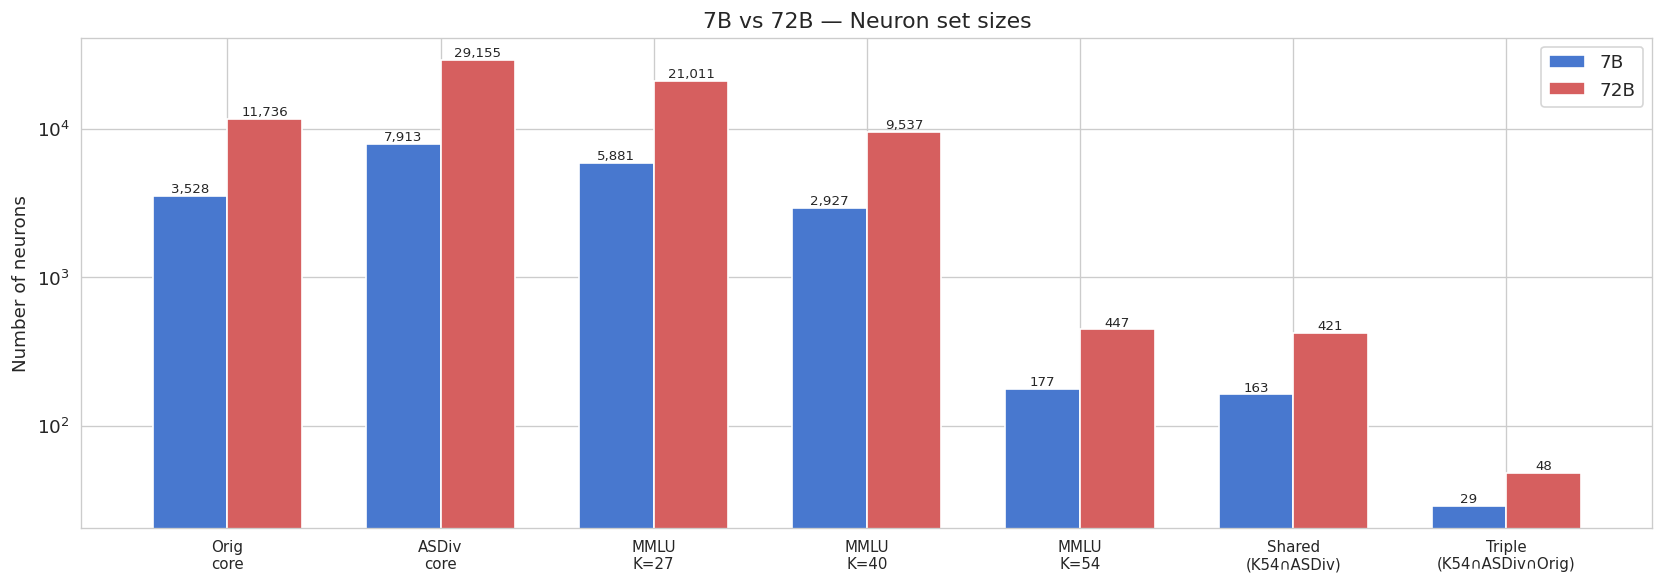

In [7]:
set_keys = ['orig_core','asdiv_core','mmlu_k27','mmlu_k40','mmlu_k54','shared','triple']
labels   = ['Orig\ncore','ASDiv\ncore','MMLU\nK=27','MMLU\nK=40','MMLU\nK=54','Shared\n(K54∩ASDiv)','Triple\n(K54∩ASDiv∩Orig)']

x  = np.arange(len(set_keys))
w  = 0.35
s7 = [len(B7[k])  for k in set_keys]
s72= [len(B72[k]) for k in set_keys]

fig, ax = plt.subplots(figsize=(14,5))
ax.bar(x-w/2, s7,  w, label='7B',  color='#4878CF', edgecolor='white')
ax.bar(x+w/2, s72, w, label='72B', color='#D65F5F', edgecolor='white')
for xi,(v7,v72) in enumerate(zip(s7,s72)):
    ax.text(xi-w/2, v7*1.05,  f'{v7:,}',  ha='center', fontsize=8)
    ax.text(xi+w/2, v72*1.05, f'{v72:,}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Number of neurons')
ax.set_title('7B vs 72B — Neuron set sizes')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('comparison_set_sizes.png', bbox_inches='tight')
plt.show()

## 3 — Layer distributions: proportional depth comparison

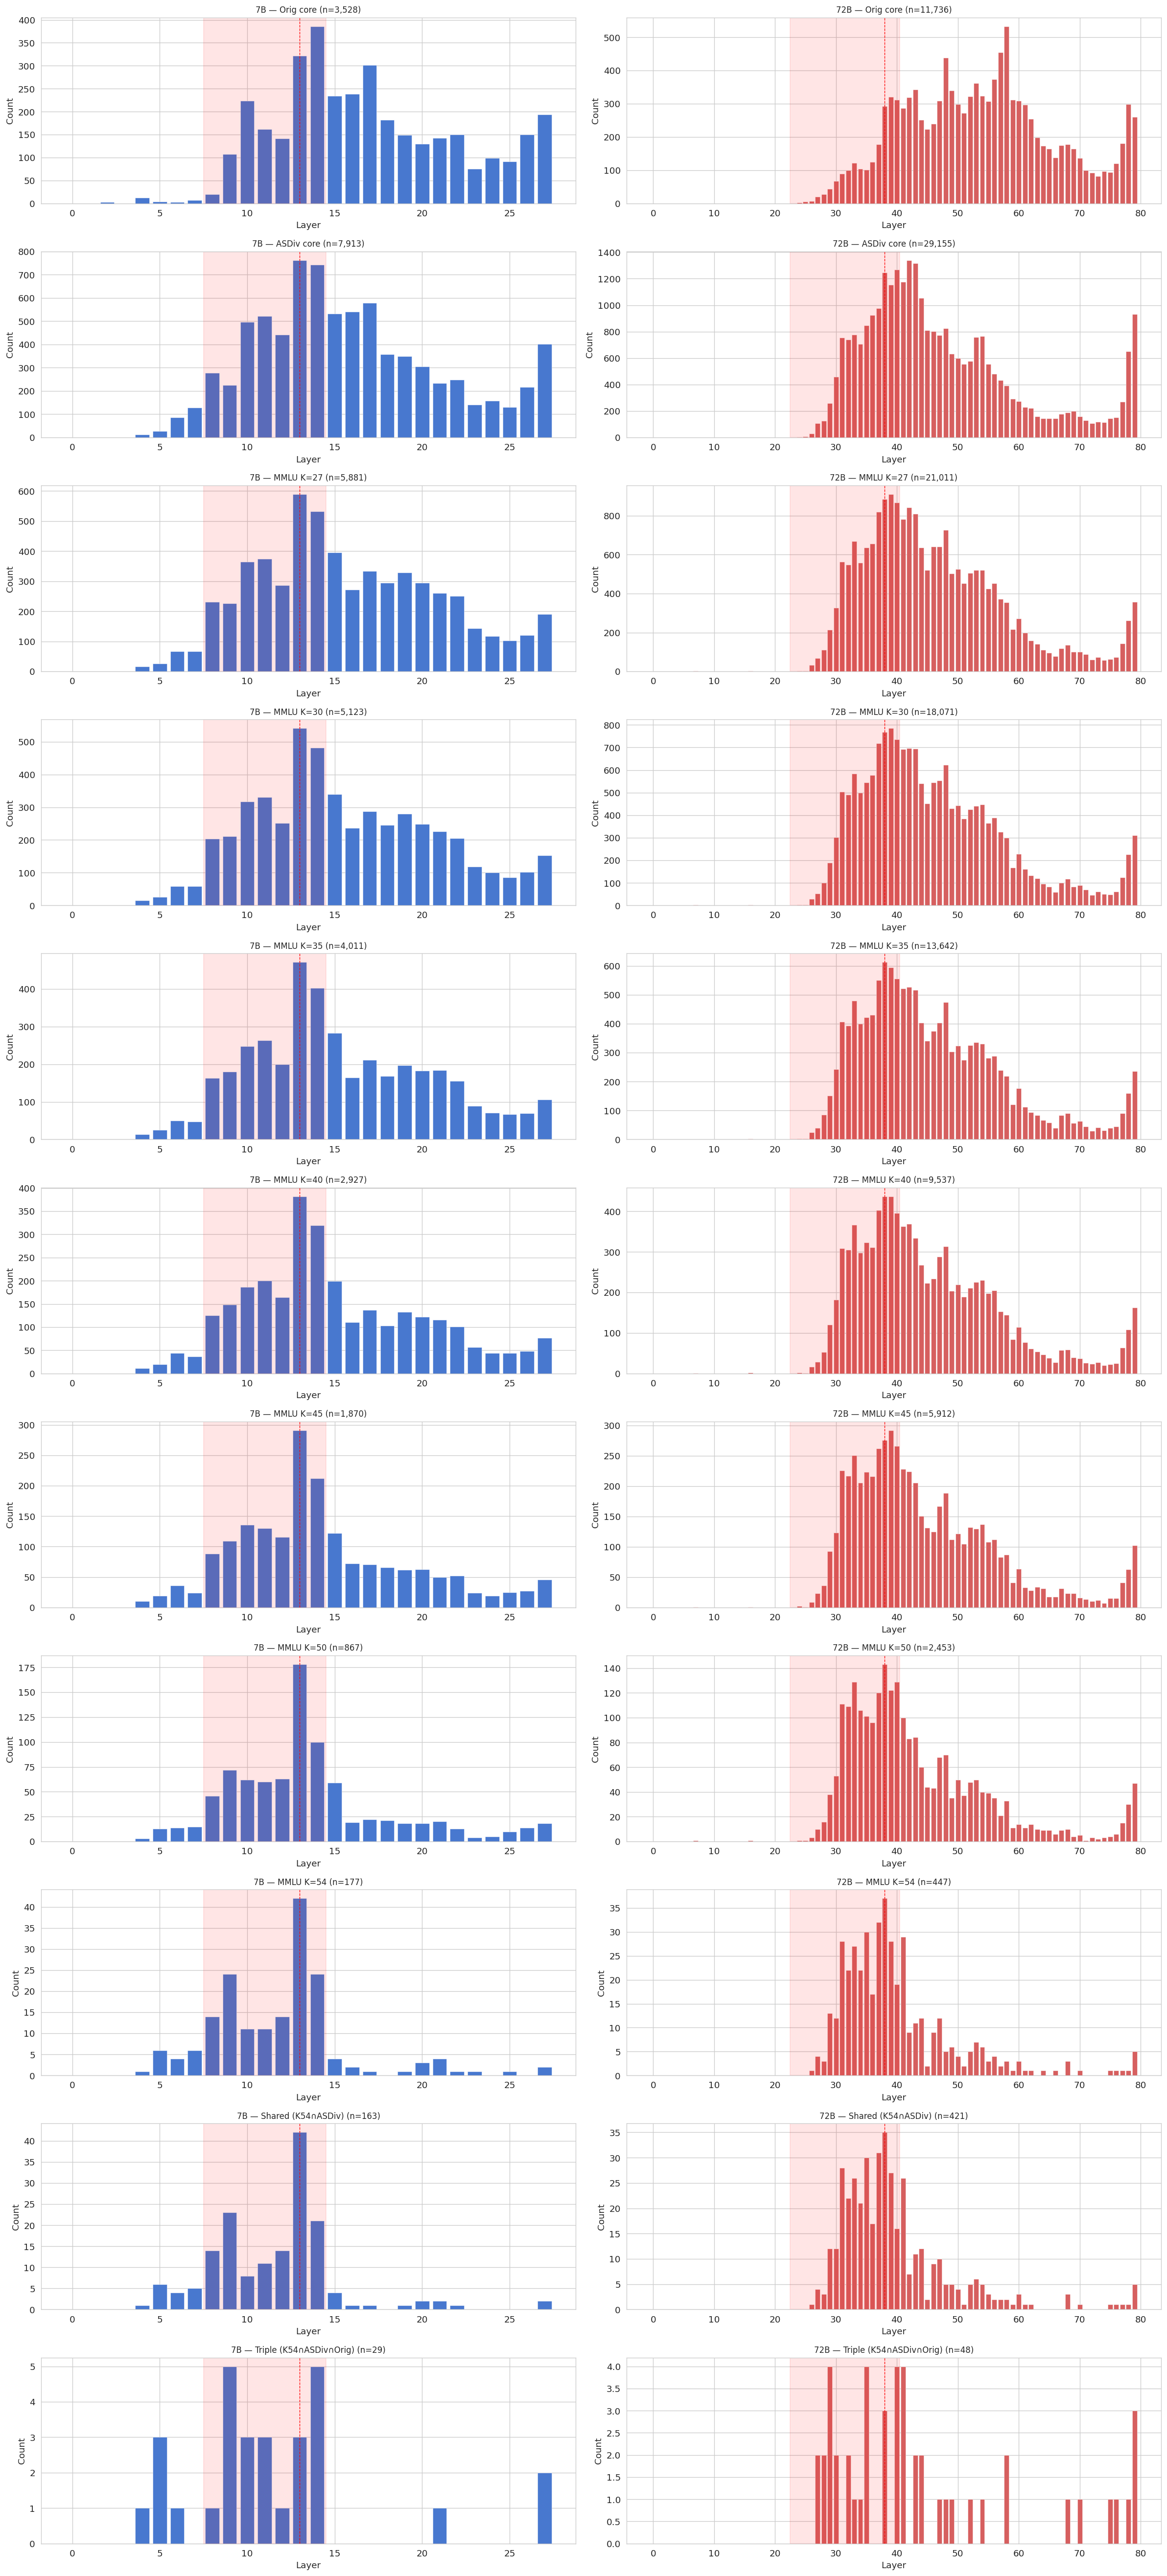

In [8]:
# All K thresholds + orig/asdiv/shared/triple — one figure per set
all_plot_keys   = ['orig_core','asdiv_core'] + [f'mmlu_k{k}' for k in K_THRESHOLDS] + ['shared','triple']
all_plot_labels = ['Orig core','ASDiv core'] + [f'MMLU K={k}' for k in K_THRESHOLDS] + ['Shared (K54∩ASDiv)','Triple (K54∩ASDiv∩Orig)']

fig, axes = plt.subplots(len(all_plot_keys), 2, figsize=(20, 4*len(all_plot_keys)))

for row, (key, label) in enumerate(zip(all_plot_keys, all_plot_labels)):
    # 7B
    d7 = layer_dist(B7[key], 28)
    axes[row,0].bar(range(28), d7, color='#4878CF', edgecolor='white', linewidth=0.3)
    axes[row,0].axvspan(7.5, 14.5, alpha=0.1, color='red')
    axes[row,0].axvline(13, color='red', linestyle='--', linewidth=0.8)
    axes[row,0].set_title(f'7B — {label} (n={len(B7[key]):,})', fontsize=10)
    axes[row,0].set_ylabel('Count')
    axes[row,0].set_xlabel('Layer')

    # 72B
    d72 = layer_dist(B72[key], 80)
    axes[row,1].bar(range(80), d72, color='#D65F5F', edgecolor='white', linewidth=0.3)
    axes[row,1].axvspan(22.5, 40.5, alpha=0.1, color='red')
    axes[row,1].axvline(38, color='red', linestyle='--', linewidth=0.8)
    axes[row,1].set_title(f'72B — {label} (n={len(B72[key]):,})', fontsize=10)
    axes[row,1].set_ylabel('Count')
    axes[row,1].set_xlabel('Layer')

# fig.suptitle('7B (left) vs 72B (right) — All K thresholds + key sets
# Red band = proportional reward zone, dashed = peak layer', fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig('comparison_layer_distributions_all_k.png', bbox_inches='tight', dpi=100)
plt.show()


## 4 — K-threshold neuron counts: 7B vs 72B

In [10]:
print(f"{'Set':<30} {'7B size':>9}  {'7B L8-14':>9}  {'72B size':>10}  {'72B L23-40':>11}  {'Scale factor':>13}")
print('-'*86)

rows = [
    ('Orig core',     'orig_core'),
    ('ASDiv core',    'asdiv_core'),
    ('MMLU K=27',     'mmlu_k27'),
    ('MMLU K=30',     'mmlu_k30'),
    ('MMLU K=35',     'mmlu_k35'),
    ('MMLU K=40',     'mmlu_k40'),
    ('MMLU K=45',     'mmlu_k45'),
    ('MMLU K=50',     'mmlu_k50'),
    ('MMLU K=54',     'mmlu_k54'),
    ('Shared (K54∩ASDiv)', 'shared'),
    ('Triple',        'triple'),
]

for label, key in rows:
    s7   = B7[key]
    s72  = B72[key]
    b7   = band_count(s7,  8,  14)
    b72  = band_count(s72, 23, 40)
    sf   = len(s72)/len(s7) if s7 else float('nan')
    print(f'{label:<30} {len(s7):>9,}  {b7:>9,}  {len(s72):>10,}  {b72:>11,}  {sf:>13.2f}x')

print('\nKey insight: reward signal lives at ~29-50% network depth in both models.')
print('Scale factor ~3x for core sets reflects larger MLP dim (29568 vs 3632).')


Set                              7B size   7B L8-14    72B size   72B L23-40   Scale factor
--------------------------------------------------------------------------------------
Orig core                          3,528      1,363      11,736        1,914           3.33x
ASDiv core                         7,913      3,465      29,155       10,375           3.68x
MMLU K=27                          5,881      2,603      21,011        7,868           3.57x
MMLU K=30                          5,123      2,337      18,071        6,887           3.53x
MMLU K=35                          4,011      1,928      13,642        5,395           3.40x
MMLU K=40                          2,927      1,524       9,537        3,988           3.26x
MMLU K=45                          1,870      1,082       5,912        2,722           3.16x
MMLU K=50                            867        581       2,453        1,288           2.83x
MMLU K=54                            177        140         447          295 

## 5 — Side-by-side layer distributions for all sets

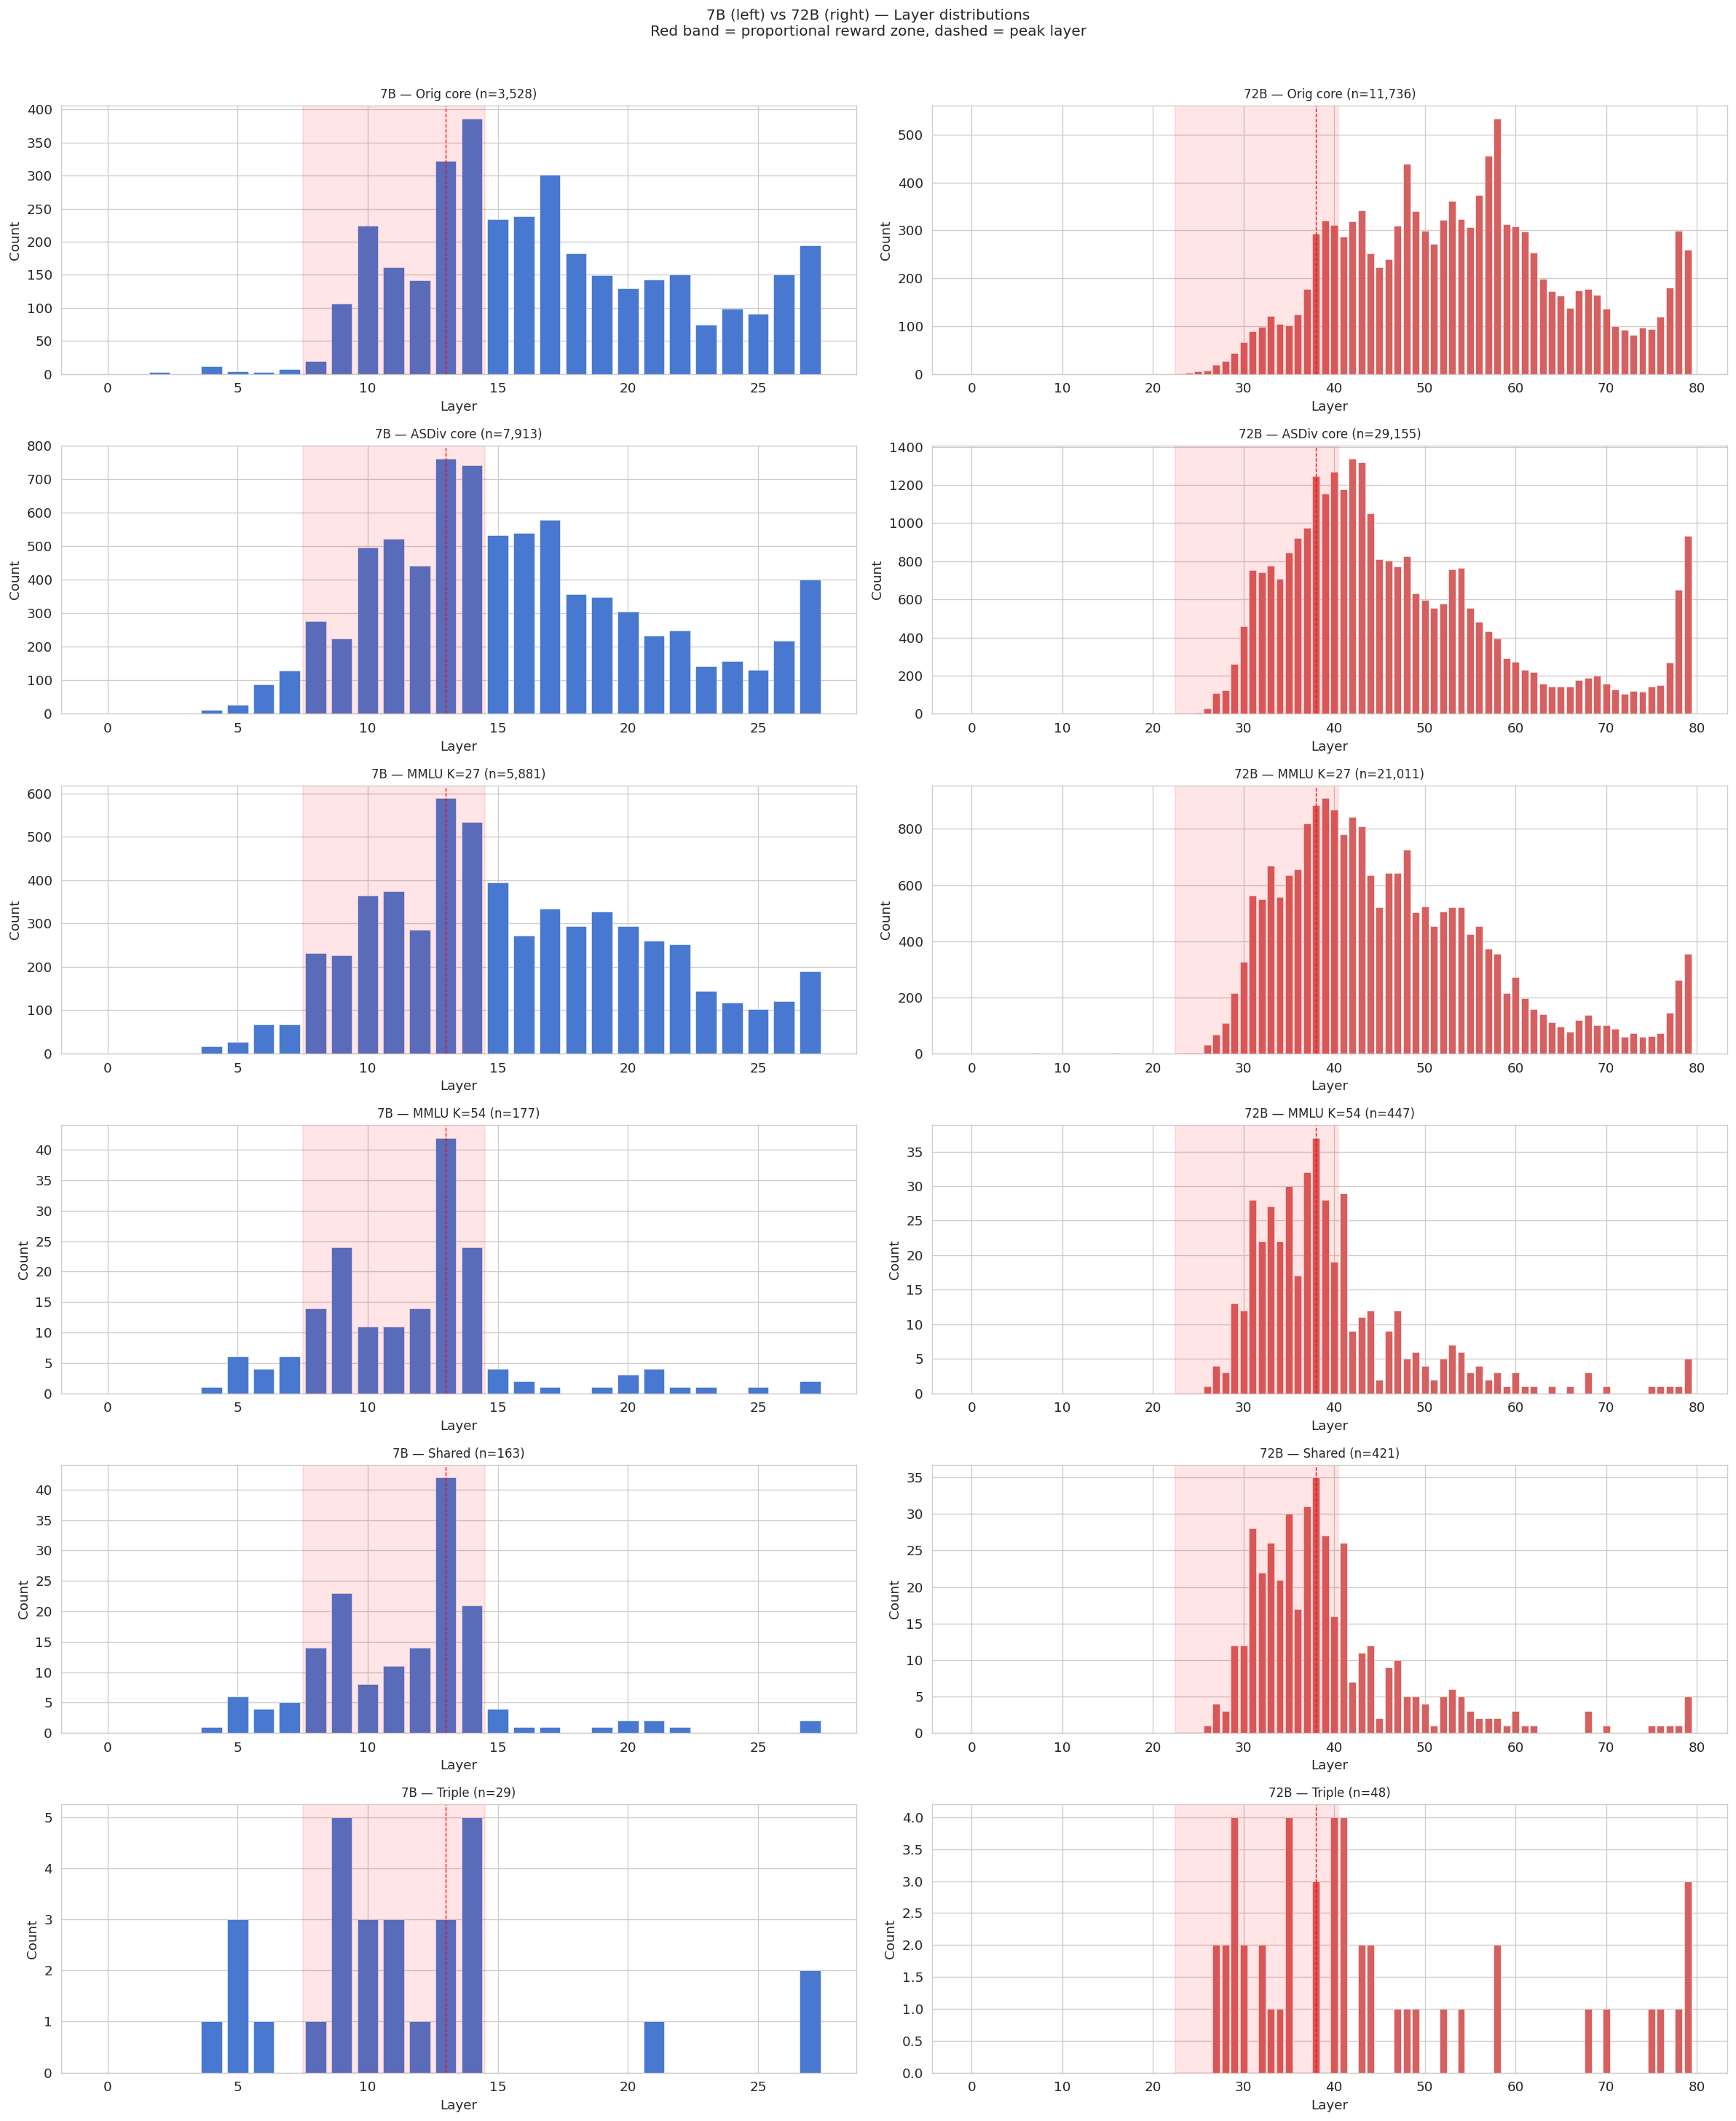

In [11]:
plot_keys = ['orig_core','asdiv_core','mmlu_k27','mmlu_k54','shared','triple']
plot_labels = ['Orig core','ASDiv core','MMLU K=27','MMLU K=54','Shared','Triple']

fig, axes = plt.subplots(len(plot_keys), 2, figsize=(20, 4*len(plot_keys)))

for row, (key, label) in enumerate(zip(plot_keys, plot_labels)):
    # 7B
    d7 = layer_dist(B7[key], 28)
    axes[row,0].bar(range(28), d7, color='#4878CF', edgecolor='white', linewidth=0.3)
    axes[row,0].axvspan(7.5, 14.5, alpha=0.1, color='red')
    axes[row,0].axvline(13, color='red', linestyle='--', linewidth=0.8)
    axes[row,0].set_title(f'7B — {label} (n={len(B7[key]):,})', fontsize=10)
    axes[row,0].set_ylabel('Count')
    axes[row,0].set_xlabel('Layer')

    # 72B
    d72 = layer_dist(B72[key], 80)
    axes[row,1].bar(range(80), d72, color='#D65F5F', edgecolor='white', linewidth=0.3)
    axes[row,1].axvspan(22.5, 40.5, alpha=0.1, color='red')
    axes[row,1].axvline(38, color='red', linestyle='--', linewidth=0.8)
    axes[row,1].set_title(f'72B — {label} (n={len(B72[key]):,})', fontsize=10)
    axes[row,1].set_ylabel('Count')
    axes[row,1].set_xlabel('Layer')

fig.suptitle('7B (left) vs 72B (right) — Layer distributions\nRed band = proportional reward zone, dashed = peak layer', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('comparison_layer_distributions.png', bbox_inches='tight')
plt.show()

## 6 — Summary table

In [13]:
print(f'{"Set":<30} {"7B size":>9}  {"7B L8-14":>9}  {"72B size":>10}  {"72B L23-40":>11}  {"Scale factor":>13}')
print('-'*86)

rows = [
    ('Orig core',     'orig_core'),
    ('ASDiv core',    'asdiv_core'),
    ('MMLU K=27',     'mmlu_k27'),
    ('MMLU K=40',     'mmlu_k40'),
    ('MMLU K=54',     'mmlu_k54'),
    ('Shared (K54∩ASDiv)', 'shared'),
    ('Triple',        'triple'),
]

for label, key in rows:
    s7   = B7[key]
    s72  = B72[key]
    b7   = band_count(s7,  8,  14)
    b72  = band_count(s72, 23, 40)
    sf   = len(s72)/len(s7) if s7 else float('nan')
    print(f'{label:<30} {len(s7):>9,}  {b7:>9,}  {len(s72):>10,}  {b72:>11,}  {sf:>13.2f}x')

print('\nKey insight: reward signal lives at ~29-50% network depth in both models.')
print('Scale factor ~3x for core sets reflects larger MLP dim (29568 vs 3632).')

Set                              7B size   7B L8-14    72B size   72B L23-40   Scale factor
--------------------------------------------------------------------------------------
Orig core                          3,528      1,363      11,736        1,914           3.33x
ASDiv core                         7,913      3,465      29,155       10,375           3.68x
MMLU K=27                          5,881      2,603      21,011        7,868           3.57x
MMLU K=40                          2,927      1,524       9,537        3,988           3.26x
MMLU K=54                            177        140         447          295           2.53x
Shared (K54∩ASDiv)                   163        133         421          285           2.58x
Triple                                29         21          48           25           1.66x

Key insight: reward signal lives at ~29-50% network depth in both models.
Scale factor ~3x for core sets reflects larger MLP dim (29568 vs 3632).
